# **RESOURCES**
## Datasets:
  [Toxicity Dataset](https://www.kaggle.com/datasets/eoveson/conversationaidataset)
  
  [Sarcasm Dataset](https://nlp.cs.princeton.edu/old/SARC/2.0/)

  [Emotion Dataset](https://kristina.machova.website.tuke.sk/useful/DATA%20for%20EMOTION%20DETECTION/)

## Collection:
  [Load Data using Tensorflow](https://www.tensorflow.org/tutorials/load_data/csv)

## Preprocessing
  [Tensorflow Text Processing](https://www.tensorflow.org/text)

  [Tensorflow Tokenization](https://www.tensorflow.org/text/guide/tokenizers)

  [Tensorflow Subword Tokenization](https://www.tensorflow.org/text/guide/subwords_tokenizer)

  [Tensorflow Vectorization and Embedding](https://medium.com/@mkk.rakesh/text-preprocessing-understanding-vectorization-and-embedding-using-tensorflow-with-simple-example-d3905b2c4692)
  
  [NLTK Text Processing](https://codefinity.com/blog/A-Comprehensive-Guide-to-Text-Preprocessing-with-NLTK)
  
  [NLTK Preprocessing Pipeline](https://spotintelligence.com/2022/12/21/nltk-preprocessing-pipeline/)

## Embedding
  [Tensorflow Word2Vec](https://www.tensorflow.org/text/tutorials/word2vec)
  
  [NLTK Word2Vec](https://medium.com/swlh/word-embedding-word2vec-with-genism-nltk-and-t-sne-visualization-43eae8ab3e2e)

  [GloVe](https://nlp.stanford.edu/projects/glove/)

## Modeling
  [Python Language Model](https://medium.com/analytics-vidhya/a-comprehensive-guide-to-build-your-own-language-model-in-python-5141b3917d6d)
  
  [Word2Vec Text Classification](https://spotintelligence.com/2023/02/15/word2vec-for-text-classification/)

# **CODE**

## *Installs*

If you receive an error because of numpy, try to restart the session and reload again.

In [ ]:
!pip install numpy==1.26.4

In [ ]:
!pip -q install nltk
!pip -q install tensorflow
!pip -q install gensim
!pip -q install ijson

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.0/149.0 kB 751.7 kB/s eta 0:00:00


## Load the required libraries and download models from NLTK

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import re
import nltk
import string
import gensim
import ijson

from sklearn.model_selection import train_test_split
from itertools import islice
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import word2vec, KeyedVectors
from nltk import word_tokenize
from google.colab import drive
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.data import Dataset
from tensorflow.keras.utils import custom_object_scope
from tensorflow.keras import Input, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Conv1D, Dropout, GlobalMaxPooling1D, Dense, Layer, MultiHeadAttention, LayerNormalization, Embedding, Bidirectional, LSTM, GlobalMaxPooling1D, Dense, Dropout, GlobalAveragePooling1D, Concatenate
from sklearn.metrics import f1_score

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

## Visualization code

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_column_distribution(column_name, dataframes, chart_label, dataframe_names=None):
    """
    Create a comparative bar chart showing distribution of a column across multiple DataFrames.

    Parameters:
    -----------
    column_name : str
        Name of the column to analyze
    dataframes : list
        List of pandas DataFrames (subsets of the same original DataFrame)
    chart_label : str
        Title/label for the chart
    dataframe_names : list, optional
        Names for each DataFrame (for legend). If None, uses 'DF 1', 'DF 2', etc.
    """

    # Validate inputs
    if not isinstance(dataframes, list) or len(dataframes) == 0:
        raise ValueError("dataframes must be a non-empty list")

    # Generate default names if not provided
    if dataframe_names is None:
        dataframe_names = [f'DF {i+1}' for i in range(len(dataframes))]
    elif len(dataframe_names) != len(dataframes):
        raise ValueError("dataframe_names must have same length as dataframes")

    # Store value counts for each dataframe
    value_counts_list = []
    raw_counts_list = []  # NEW: Store raw counts

    # Get value counts for each dataframe
    for i, df in enumerate(dataframes):
        if column_name not in df.columns:
            print(f"Warning: Column '{column_name}' not found in dataframe {i+1}")
            value_counts_list.append(pd.Series(dtype='float64'))
            raw_counts_list.append(pd.Series(dtype='int64'))  # NEW
        else:
            # Get raw counts
            raw_counts = df[column_name].value_counts()  # NEW
            # Get percentages
            value_counts = df[column_name].value_counts(normalize=True) * 100
            value_counts_list.append(value_counts)
            raw_counts_list.append(raw_counts)  # NEW

    # Get all unique values across all dataframes
    all_values = set()
    for counts in value_counts_list:
        all_values.update(counts.index)
    all_values = sorted(list(all_values))

    # Create data matrix for plotting
    n_values = len(all_values)
    n_dataframes = len(dataframes)

    # Initialize matrices with NaN (for missing values)
    data_matrix = np.full((n_values, n_dataframes), np.nan)
    count_matrix = np.full((n_values, n_dataframes), np.nan)  # NEW: matrix for raw counts

    # Fill matrix with percentages AND raw counts
    for df_idx, (percentages, counts) in enumerate(zip(value_counts_list, raw_counts_list)):
        for val_idx, value in enumerate(all_values):
            if value in percentages.index:
                data_matrix[val_idx, df_idx] = percentages[value]
                count_matrix[val_idx, df_idx] = counts[value]  # NEW

    # Set up the plot
    fig, ax = plt.subplots(figsize=(max(10, n_values * 0.8), 6))

    # Set bar width and positions
    bar_width = 0.8 / n_dataframes
    x_positions = np.arange(n_values)

    # Create bars for each dataframe
    colors = plt.cm.Set3(np.linspace(0, 1, n_dataframes))  # Color palette

    bars = []
    for i in range(n_dataframes):
        bar_positions = x_positions + i * bar_width - (bar_width * (n_dataframes - 1) / 2)
        bars.append(ax.bar(bar_positions, data_matrix[:, i],
                          width=bar_width,
                          label=dataframe_names[i],
                          color=colors[i],
                          edgecolor='black',
                          linewidth=0.5))

    # Add value labels on top of bars
    for i, bar_group in enumerate(bars):
        for j, bar in enumerate(bar_group):
            height = bar.get_height()
            if not np.isnan(height):
                # Get the raw count from count_matrix
                count_val = count_matrix[j, i]  # FIXED: Now properly defined
                if not np.isnan(count_val):
                    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                          f'{height:.1f}% ({int(count_val)})',
                          ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Customize the plot
    ax.set_xlabel(column_name, fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_title(f'{chart_label}', fontsize=14, pad=20)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(all_values, rotation=45, ha='right')
    ax.legend(title='Data Subsets')

    # Add grid for better readability
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    # Adjust y-limit to accommodate labels
    ymax = np.nanmax(data_matrix)
    ax.set_ylim(0, ymax * 1.25 if not np.isnan(ymax) else 100)  # Increased from 1.15 to 1.25

    # Add a horizontal line at 0
    ax.axhline(y=0, color='black', linewidth=0.5)

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Return the data matrix for further analysis if needed
    return pd.DataFrame(data_matrix, index=all_values, columns=dataframe_names)


# Alternative: Stacked bar chart version (with counts added)
def plot_column_distribution_stacked(column_name, dataframes, chart_label, dataframe_names=None):
    """
    Create a stacked bar chart showing distribution of a column across multiple DataFrames.
    """

    if dataframe_names is None:
        dataframe_names = [f'DF {i+1}' for i in range(len(dataframes))]

    # Get value counts for each dataframe
    value_counts_list = []
    raw_counts_list = []  # NEW

    for i, df in enumerate(dataframes):
        if column_name not in df.columns:
            print(f"Warning: Column '{column_name}' not found in dataframe {i+1}")
            value_counts_list.append(pd.Series(dtype='float64'))
            raw_counts_list.append(pd.Series(dtype='int64'))  # NEW
        else:
            raw_counts = df[column_name].value_counts()  # NEW
            value_counts = df[column_name].value_counts(normalize=True) * 100
            value_counts_list.append(value_counts)
            raw_counts_list.append(raw_counts)  # NEW

    # Get all unique values
    all_values = set()
    for counts in value_counts_list:
        all_values.update(counts.index)
    all_values = sorted(list(all_values))

    # Create stacked data
    n_values = len(all_values)
    n_dataframes = len(dataframes)

    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(10, n_values * 0.8), 10),
                                   gridspec_kw={'height_ratios': [3, 1]})

    # Colors for different categories
    category_colors = plt.cm.tab20c(np.linspace(0, 1, n_values))

    # Plot stacked bars for each dataframe
    bottom_values = np.zeros(n_dataframes)

    for val_idx, value in enumerate(all_values):
        percentages = []
        counts = []  # NEW
        labels = []
        for df_idx, (pct_series, cnt_series) in enumerate(zip(value_counts_list, raw_counts_list)):
            if value in pct_series.index:
                percentages.append(pct_series[value])
                counts.append(int(cnt_series[value]))  # NEW
                labels.append(value)
            else:
                percentages.append(0)
                counts.append(0)  # NEW

        bars = ax1.bar(range(n_dataframes), percentages, bottom=bottom_values,
                color=category_colors[val_idx], label=value, edgecolor='black')

        # Add labels to each segment
        for bar_idx, (bar, count_val) in enumerate(zip(bars, counts)):
            if percentages[bar_idx] > 0:  # Only label non-zero segments
                # Calculate position for label
                segment_height = percentages[bar_idx]
                segment_bottom = bottom_values[bar_idx]
                label_y = segment_bottom + segment_height / 2

                # Add label if segment is tall enough
                if segment_height > 5:  # Minimum height for label
                    ax1.text(bar_idx, label_y,
                            f'{segment_height:.1f}%\n(n={count_val})\nlabel={labels[bar_idx]}',
                            ha='center', va='center',
                            fontsize=8, fontweight='bold',
                            color='white')

        bottom_values += percentages

    # Customize main chart
    ax1.set_xlabel('Data Subsets', fontsize=12)
    ax1.set_ylabel('Percentage (%)', fontsize=12)
    ax1.set_title(f'{chart_label}\nStacked Distribution of "{column_name}"', fontsize=14, pad=20)
    ax1.set_xticks(range(n_dataframes))
    ax1.set_xticklabels(dataframe_names, rotation=45, ha='right')
    ax1.legend(title=column_name, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax1.set_axisbelow(True)

    # Create a summary table below with counts
    table_data = []
    for pct_series, cnt_series in zip(value_counts_list, raw_counts_list):
        row = []
        for value in all_values:
            if value in pct_series.index:
                row.append(f'{pct_series[value]:.1f}%\n(n={int(cnt_series[value])})')
            else:
                row.append('0%\n(n=0)')
        table_data.append(row)

    # Plot table
    ax2.axis('tight')
    ax2.axis('off')
    table = ax2.table(cellText=table_data,
                     rowLabels=dataframe_names,
                     colLabels=all_values,
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, metrics=None):
    """
    Plot training metrics from Keras history object.

    Parameters:
    -----------
    history : keras.callbacks.History or dict
        History object returned by model.fit() or a dictionary with history
    metrics : list, optional
        List of metrics to plot. If None, plots all available metrics
    """

    # Convert history to dictionary if it's a History object
    if hasattr(history, 'history'):
        history_dict = history.history
    else:
        history_dict = history

    # Get available metrics
    if metrics is None:
        # Plot all metrics except 'lr' if present
        metrics = [m for m in history_dict.keys() if m != 'lr']

    # Determine number of plots (1 row, n columns)
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(5*n_metrics, 4))

    # If only one metric, axes won't be an array
    if n_metrics == 1:
        axes = [axes]

    epochs = range(1, len(history_dict[metrics[0]]) + 1)

    for idx, metric in enumerate(metrics):
        ax = axes[idx]

        # Plot training metric
        train_values = history_dict.get(metric)
        if train_values:
            ax.plot(epochs, train_values, 'b-', label=f'Training {metric}', linewidth=2)

        # Plot validation metric if available
        val_metric = f'val_{metric}'
        val_values = history_dict.get(val_metric)
        if val_values:
            ax.plot(epochs, val_values, 'r-', label=f'Validation {metric}', linewidth=2)

        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'{metric.capitalize()} per Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# For more detailed analysis
def plot_detailed_training(history):
    """
    More detailed plotting with all metrics in separate subplots.
    """

    if hasattr(history, 'history'):
        history_dict = history.history
    else:
        history_dict = history

    # Get metrics (exclude learning rate if present)
    metrics = [m for m in history_dict.keys() if m != 'lr']

    n_plots = len(metrics)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]

    epochs = range(1, len(history_dict[metrics[0]]) + 1)

    for idx, metric in enumerate(metrics):
        ax = axes[idx]

        # Plot training metric
        train_values = history_dict[metric]
        ax.plot(epochs, train_values, 'b-', linewidth=2, label='Training')

        # Check for validation metric
        if metric.startswith('val_'):
            # This is already a validation metric, find corresponding training metric
            train_metric = metric[4:]  # Remove 'val_' prefix
            if train_metric in history_dict:
                ax.plot(epochs, history_dict[train_metric], 'r-', linewidth=2, label='Training')
                ax.set_title(f'{train_metric.capitalize()}')
            else:
                ax.set_title(f'{metric.capitalize()}')
        else:
            # Check for validation version
            val_metric = f'val_{metric}'
            if val_metric in history_dict:
                ax.plot(epochs, history_dict[val_metric], 'r-', linewidth=2, label='Validation')
            ax.set_title(f'{metric.capitalize()}')

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Value')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(len(metrics), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(prediction_labels, real_labels, class_names=None, normalize=False, title=None):
    """
    Plot a confusion matrix between prediction_labels and real_labels.

    Parameters:
    -----------
    prediction_labels : array-like
        Predicted labels
    real_labels : array-like
        True/actual labels
    class_names : list, optional
        Names of the classes. If None, uses integer labels.
    normalize : bool or str, default=False
        If True, normalizes confusion matrix by true labels.
        If 'pred', normalizes by predicted labels.
        If 'all', normalizes by total samples.
    title : str, optional
        Title for the plot. If None, auto-generates based on parameters.
    """

    # Convert to numpy arrays if needed
    pred = np.array(prediction_labels)
    real = np.array(real_labels)

    # Create confusion matrix
    cm = confusion_matrix(real, pred)

    # Normalize if requested
    if normalize:
        if normalize == 'pred':
            cm = cm.astype('float') / (cm.sum(axis=0)[np.newaxis, :] + 1e-10)
            fmt = '.2f'
        elif normalize == 'all':
            cm = cm.astype('float') / cm.sum()
            fmt = '.3f'
        else:  # normalize by true labels (default)
            cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
            fmt = '.2f'
        cm_display = cm
    else:
        cm_display = cm
        fmt = 'd'

    # Get class names
    if class_names is None:
        unique_labels = np.unique(np.concatenate([real, pred]))
        class_names = [str(label) for label in unique_labels]

    # Create figure
    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(6, len(class_names) * 0.7)))

    # Create heatmap
    sns.heatmap(cm_display, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Normalized Count' if normalize else 'Count'},
                ax=ax)

    # Set labels and title
    ax.set_xlabel('Predicted Labels', fontsize=12)
    ax.set_ylabel('True Labels', fontsize=12)

    if title is None:
        title = 'Confusion Matrix'
        if normalize:
            if normalize == 'pred':
                title += ' (Normalized by Predictions)'
            elif normalize == 'all':
                title += ' (Normalized by Total)'
            else:
                title += ' (Normalized by True Labels)'

    ax.set_title(title, fontsize=14, pad=20)

    # Rotate tick labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    plt.setp(ax.get_yticklabels(), rotation=0, ha='right')

    # Adjust layout
    plt.tight_layout()
    plt.show()

    # Return confusion matrix for further analysis
    return cm


# Alternative version with more detailed metrics
def plot_detailed_confusion_matrix(prediction_labels, real_labels, class_names=None):
    """
    Plot confusion matrix with per-class metrics.
    """

    pred = np.array(prediction_labels)
    real = np.array(real_labels)

    # Create confusion matrix
    cm = confusion_matrix(real, pred)

    # Get class names
    if class_names is None:
        unique_labels = np.unique(np.concatenate([real, pred]))
        class_names = [str(label) for label in unique_labels]

    # Normalized confusion matrix
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)

    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Raw confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'},
                ax=axes[0])
    axes[0].set_xlabel('Predicted Labels', fontsize=12)
    axes[0].set_ylabel('True Labels', fontsize=12)
    axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, pad=20)

    # Plot 2: Normalized confusion matrix
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Proportion'},
                ax=axes[1])
    axes[1].set_xlabel('Predicted Labels', fontsize=12)
    axes[1].set_ylabel('True Labels', fontsize=12)
    axes[1].set_title('Confusion Matrix (Normalized by True Labels)', fontsize=14, pad=20)

    # Rotate tick labels
    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
        plt.setp(ax.get_yticklabels(), rotation=0, ha='right')

    plt.tight_layout()
    plt.show()

    # Calculate and print per-class metrics
    n_classes = len(class_names)
    print("\nPer-class Metrics:")
    print("-" * 60)
    print(f"{'Class':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
    print("-" * 60)

    for i in range(n_classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp

        precision = tp / (tp + fp + 1e-10)
        recall = tp / (tp + fn + 1e-10)
        f1 = 2 * precision * recall / (precision + recall + 1e-10)

        print(f"{class_names[i]:<10} {precision:<10.3f} {recall:<10.3f} {f1:<10.3f}")

    # Overall accuracy
    accuracy = np.sum(pred == real) / len(real)
    print("-" * 60)
    print(f"Overall Accuracy: {accuracy:.4f}")
    print("-" * 60)

    return cm

## *Load the Datasets*

 - Load the files from Google Drive
   - If this errors out, make a shortcut of the folder linked below on the root of your drive, then try again.
 - Load the toxicity dataset's comments and annotations
 - Specify the labels for each entry in the original comment dataframe as either a 1 (if toxic) or 0 (if non toxic)



In [ ]:
drive.mount('/content/drive', force_remount=True)

if os.path.exists('/content/drive/MyDrive/Colab Files'):
  os.chdir('/content/drive/MyDrive/Colab Files/Thesis')
else:
  try:
    os.chdir('/content/drive/MyDrive/Thesis')
  except FileNotFoundError as fnfe:
    raise FileNotFoundError('\033[91mThesis Folder in MyDrive does not exists, create a shortcut or a copy of this folder: https://drive.google.com/drive/folders/1lzb-xPgg0qE2iIsb9Cn3SDptGJ9J09Lk?usp=drive_link \033[0m') from fnfe

Mounted at /content/drive


### Toxicity Dataset

Each entry in the toxicity_label_dataset dataframe is a review by a human
reviewer with a column stating how toxic they perceive the comment to be

In [ ]:
# Read the toxicity dataset
toxicity_df = pd.read_csv('toxicity_annotated_comments.tsv', delimiter='\t', usecols=[0, 1, 6] )
tox_label = pd.read_csv('toxicity_annotations.tsv', delimiter='\t')
print("The toxicity dataset have been loaded.")

net_toxicity_dict = {}

# iterate over tox_label, adding their toxicity_score and putting it in a dictionary
for index, row in tox_label.iterrows():
  row_value = row['rev_id']

  if row_value not in net_toxicity_dict:
    net_toxicity_dict[row_value] = row['toxicity_score'].item()
  else:
    net_toxicity_dict[row_value] = net_toxicity_dict.get(row_value) + row['toxicity_score'].item()

# converts net_toxicity_dict's range from all integers to just 1 if negative, else 0
toxicity_dict = dict(map(lambda x: (x[0], 1 if x[1] < 0 else 0), net_toxicity_dict.items()))
toxicity_df['toxicity'] = toxicity_df['rev_id'].map(toxicity_dict)

The toxicity dataset have been loaded.


In [ ]:
toxicity_counts = toxicity_df['toxicity'].value_counts()
toxic_count = toxicity_counts[1]
non_toxic_count = toxicity_counts[0]

print()
print('\033[92mtoxic count:', toxic_count)
print('non_toxic count:', non_toxic_count)
print('total count of toxicity dataset: ', len(toxicity_df))
print('\ntoxic percentage:', toxic_count * 100 / len(toxicity_df))
print('non_toxic percentage:', non_toxic_count * 100 / len(toxicity_df), '\033[0m')




toxic count: 29457
non_toxic count: 130229
total count of toxicity dataset:  159686

toxic percentage: 18.446826897786906
non_toxic percentage: 81.5531731022131 


### Sarcasm Dataset

Load the sarcasm dataset into a single dataframe with columns text, split, sarcastic

In [ ]:
# load the sarcasm dataset
def load_sarcasm_dataset(train_path, test_path):
  comments_path = 'sarc_comments.json'
  train_labels = {}
  test_labels = {}
  train_row = []
  test_row = []

  # loads the ids and their labels from training set
  with open('sarc_train_balanced.csv', 'r') as f:
    for line in f:
      sep = line.strip().split('|')
      id = sep[1].split()
      label = sep[2].split()

      for i in range(len(id)):
        train_labels[id[i]] = int(label[i])

  # loads the ids and their labels from test
  with open('sarc_test_balanced.csv', 'r') as f:
    for line in f:
      sep = line.strip().split('|')
      id = sep[1].split()
      label = sep[2].split()

      for i in range(len(id)):
        test_labels[id[i]] = int(label[i])

  # loads ids and their text
  with open('sarc_comments.json', 'r') as f:
    parse = ijson.kvitems(f, '')
    for key, value in parse:
      if key in train_labels:
        train_row.append({'id' : key, 'author' : value.get('author'), 'text' : value.get('text'), 'split' : 'train'})
      elif key in test_labels:
        test_row.append({'id' : key, 'author' : value.get('author'), 'text' : value.get('text'), 'split' : 'test'})

  # convert to dataframe
  train_df = pd.DataFrame(train_row)
  test_df = pd.DataFrame(test_row)
  train_df['sarcastic'] = train_df['id'].map(train_labels)
  test_df['sarcastic'] = test_df['id'].map(test_labels)
  combined_df = pd.concat([train_df, test_df], ignore_index=True)

  return combined_df

# Load the sarcasm dataset for sarcasm detection
sarcasm_df = load_sarcasm_dataset('sarc_train_balanced.csv', 'sarc_test_balanced.csv')
sarcasm_df

,id,author,text,split,sarcastic
0,c07fd66,Reedzit,Religion must have the answer,train,1
1,c07f3md,rodneykm,Wow...he smoked pot...oh lord hes such a horri...,train,1
2,c07it38,mellowmonk,Another idea from the party that wants to get ...,train,1
3,c07jfvv,Erobern,"Oh right, *both* wars were just jewish conspir...",train,1
4,c07o37s,Mastrmind,Good luck with that.,train,1
...,...,...,...,...,...
321743,dfo7hv8,OMGKohai,Rake skins ;D,test,0
321744,dfo8294,1lecamaro2013,Well if you're going to be stupid why not docu...,test,0
321745,dfolvl0,conanap,THEYRE SO CUTE,test,0
321746,dfowme8,Germanhammer05,I'm very curious to see if they'll actually fo...,test,0


In [ ]:
sarcastic_counts = sarcasm_df['sarcastic'].value_counts()
sarcastic_count = sarcastic_counts[1]
non_sarcastic_count = sarcastic_counts[0]

print()
print('\033[92msarcastic_count count:', sarcastic_count)
print('non_sarcastic_count count:', non_sarcastic_count)
print('total count of sarcasm dataset:', len(sarcasm_df))
print('\nsarcastic percentage:', sarcastic_count * 100 / len(sarcasm_df))
print('nonsarcastic percentage:', non_sarcastic_count * 100 / len(sarcasm_df), '\033[0m')



sarcastic_count count: 160874
non_sarcastic_count count: 160874
total count of sarcasm dataset: 321748

sarcastic percentage: 50.0
nonsarcastic percentage: 50.0 


### Emotion Dataset

In [ ]:
emo_train = pd.read_csv('emotion_train.txt', delimiter=';', header=None)
emo_train.columns = ['comments', 'emotion']
emo_train['split'] = 'train'

emo_val = pd.read_csv('emotion_val.txt', delimiter=';', header=None)
emo_val.columns = ['comments', 'emotion']
emo_val['split'] = 'val'

emo_test = pd.read_csv('emotion_test.txt', delimiter=';', header=None)
emo_test.columns = ['comments', 'emotion']
emo_test['split'] = 'test'


emotion_combined_df = pd.concat([emo_train, emo_val, emo_test], ignore_index=True)

# Convert text emotion labels into numbers and store inside emotion_encoded column for training
emotion_combined_df['emotion_encoded'] = ''
emotion_dict = { 'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5 }
emotion_combined_df['emotion_encoded'] = emotion_combined_df['emotion'].map(emotion_dict)

emotion_combined_df

,comments,emotion,split,emotion_encoded
0,i didnt feel humiliated,sadness,train,4
1,i can go from feeling so hopeless to so damned...,sadness,train,4
2,im grabbing a minute to post i feel greedy wrong,anger,train,0
3,i am ever feeling nostalgic about the fireplac...,love,train,3
4,i am feeling grouchy,anger,train,0
...,...,...,...,...
19995,i just keep feeling like someone is being unki...,anger,test,0
19996,im feeling a little cranky negative after this...,anger,test,0
19997,i feel that i am useful to my people and that ...,joy,test,2
19998,im feeling more comfortable with derby i feel ...,joy,test,2


In [ ]:
emotion_counts = emotion_combined_df['emotion'].value_counts()
emotion_counts_df = emotion_counts.reset_index()
emotion_counts_df.columns = ['emotion', 'count']  # rename columns

# Add percentage column
emotion_counts_df['percentage'] = (emotion_counts_df['count'] / (len(emotion_combined_df)) * 100).round(2)
emotion_counts_df

,emotion,count,percentage
0,joy,6761,33.80
1,sadness,5797,28.98
2,anger,2709,13.54
3,fear,2373,11.86
4,love,1641,8.20
5,surprise,719,3.60


## *Preprocessing*

In [ ]:
# for cleaning the text
def clean_text(comment):
  comment = str(comment)
  comment = re.sub('#', '', comment)                  # removal of hashtags
  comment = re.sub(r'https?:\/\/.*\s?', '', comment)  # removal of links
  comment = re.sub(r'\S+@\S+\s?', '', comment)        # removal of email?
  comment = re.sub('NEWLINE_TOKEN:?', '. ', comment)  # removal of newline token
  comment = re.sub('`', '', comment)                  # removal of backticks
  comment = comment.lower().strip()                   # lowercase then remove padding

  return comment

In [ ]:
# tokenization, removal of stopwords and punctuation removal, and finally lemmatization
stopping_words = stopwords.words('english')
lemmatizer = WordNetLemmatizer()

USE_STOPWORDS = False;
def cleaner_function(comment):
  tokens = word_tokenize(comment)

  if USE_STOPWORDS == False:
    return [lemmatizer.lemmatize(token) for token in tokens if token not in string.punctuation]
  else:
    return [lemmatizer.lemmatize(token) for token in tokens if token not in stopping_words and token not in string.punctuation]

### Toxicity Preprocessing

In [ ]:
# apply clean_text over the entire toxicity dataset and print the contents
toxicity_df['cleaned_comment'] = toxicity_df['comment'].apply(clean_text)

toxicity_df

,rev_id,comment,split,toxicity,cleaned_comment
0,2232.0,This:NEWLINE_TOKEN:One can make an analogy in ...,train,0,this:. one can make an analogy in mathematical...
1,4216.0,`NEWLINE_TOKENNEWLINE_TOKEN:Clarification for ...,train,0,. . clarification for you (and zundark's righ...
2,8953.0,Elected or Electoral? JHK,test,0,elected or electoral? jhk
3,26547.0,`This is such a fun entry. DevotchkaNEWLINE_...,train,0,this is such a fun entry. devotchka. . i onc...
4,28959.0,Please relate the ozone hole to increases in c...,test,0,please relate the ozone hole to increases in c...
...,...,...,...,...,...
159681,699848324.0,`NEWLINE_TOKENNEWLINE_TOKENNEWLINE_TOKENThese ...,train,0,. . . these sources don't exactly exude a sens...
159682,699851288.0,NEWLINE_TOKENNEWLINE_TOKENThe Institute for Hi...,test,0,. . the institute for historical review is a p...
159683,699857133.0,NEWLINE_TOKEN:The way you're trying to describ...,dev,0,. the way you're trying to describe it in this...
159684,699891012.0,NEWLINE_TOKENNEWLINE_TOKEN== Warning ==NEWLINE...,train,1,. . == warning ==. . there is clearly a protec...


In [ ]:
# tokenize, remove stopwords, and lemmatize the cleaned comments inside the toxicity_df
toxicity_df['tokens'] = toxicity_df['cleaned_comment'].apply(cleaner_function)

toxicity_df

,rev_id,comment,split,toxicity,cleaned_comment,tokens
0,2232.0,This:NEWLINE_TOKEN:One can make an analogy in ...,train,0,this:. one can make an analogy in mathematical...,"[this, one, can, make, an, analogy, in, mathem..."
1,4216.0,`NEWLINE_TOKENNEWLINE_TOKEN:Clarification for ...,train,0,. . clarification for you (and zundark's righ...,"[clarification, for, you, and, zundark, 's, ri..."
2,8953.0,Elected or Electoral? JHK,test,0,elected or electoral? jhk,"[elected, or, electoral, jhk]"
3,26547.0,`This is such a fun entry. DevotchkaNEWLINE_...,train,0,this is such a fun entry. devotchka. . i onc...,"[this, is, such, a, fun, entry, devotchka, i, ..."
4,28959.0,Please relate the ozone hole to increases in c...,test,0,please relate the ozone hole to increases in c...,"[please, relate, the, ozone, hole, to, increas..."
...,...,...,...,...,...,...
159681,699848324.0,`NEWLINE_TOKENNEWLINE_TOKENNEWLINE_TOKENThese ...,train,0,. . . these sources don't exactly exude a sens...,"[these, source, do, n't, exactly, exude, a, se..."
159682,699851288.0,NEWLINE_TOKENNEWLINE_TOKENThe Institute for Hi...,test,0,. . the institute for historical review is a p...,"[the, institute, for, historical, review, is, ..."
159683,699857133.0,NEWLINE_TOKEN:The way you're trying to describ...,dev,0,. the way you're trying to describe it in this...,"[the, way, you, 're, trying, to, describe, it,..."
159684,699891012.0,NEWLINE_TOKENNEWLINE_TOKEN== Warning ==NEWLINE...,train,1,. . == warning ==. . there is clearly a protec...,"[==, warning, ==, there, is, clearly, a, prote..."


In [ ]:
# split the main dataset into three subdatasets for training / validation / testing
toxicity_train_set = toxicity_df[toxicity_df["split"] == "train"]
toxicity_val_set = toxicity_df[toxicity_df["split"] == "dev"]
toxicity_test_set = toxicity_df[toxicity_df["split"] == "test"]

print('\033[92mtraining set size:', len(toxicity_train_set), ', percentage:', len(toxicity_train_set) * 100 / len(toxicity_df))
print('validation set size:', len(toxicity_val_set), ', percentage:', len(toxicity_val_set) * 100 / len(toxicity_df))
print('testing set size:', len(toxicity_test_set), ', percentage:', len(toxicity_test_set) * 100 / len(toxicity_df), '\033[0m')

toxicity_train_set

training set size: 95692 , percentage: 59.925103014666284
validation set size: 32128 , percentage: 20.119484488308306
testing set size: 31866 , percentage: 19.955412497025414 


,rev_id,comment,split,toxicity,cleaned_comment,tokens
0,2232.0,This:NEWLINE_TOKEN:One can make an analogy in ...,train,0,this:. one can make an analogy in mathematical...,"[this, one, can, make, an, analogy, in, mathem..."
1,4216.0,`NEWLINE_TOKENNEWLINE_TOKEN:Clarification for ...,train,0,. . clarification for you (and zundark's righ...,"[clarification, for, you, and, zundark, 's, ri..."
3,26547.0,`This is such a fun entry. DevotchkaNEWLINE_...,train,0,this is such a fun entry. devotchka. . i onc...,"[this, is, such, a, fun, entry, devotchka, i, ..."
6,37330.0,`NEWLINE_TOKENNEWLINE_TOKENNEWLINE_TOKENI fixe...,train,0,. . . i fixed the link; i also removed homeopa...,"[i, fixed, the, link, i, also, removed, homeop..."
7,37346.0,`If they are ``indisputable`` then why does th...,train,0,if they are indisputable then why does the noa...,"[if, they, are, indisputable, then, why, doe, ..."
...,...,...,...,...,...,...
159678,699822249.0,`NEWLINE_TOKENNEWLINE_TOKEN:``Comment````. Gen...,train,0,". . comment. gentlemen, this article provides ...","[comment, gentleman, this, article, provides, ..."
159679,699826615.0,NEWLINE_TOKEN*Support and recommend moving thi...,train,0,. *support and recommend moving this (and my r...,"[support, and, recommend, moving, this, and, m..."
159680,699843603.0,`NEWLINE_TOKENNEWLINE_TOKEN== File:Romantic Wa...,train,0,. . == file:romantic warriors cover.jpg ==. . ...,"[==, file, romantic, warrior, cover.jpg, ==, y..."
159681,699848324.0,`NEWLINE_TOKENNEWLINE_TOKENNEWLINE_TOKENThese ...,train,0,. . . these sources don't exactly exude a sens...,"[these, source, do, n't, exactly, exude, a, se..."


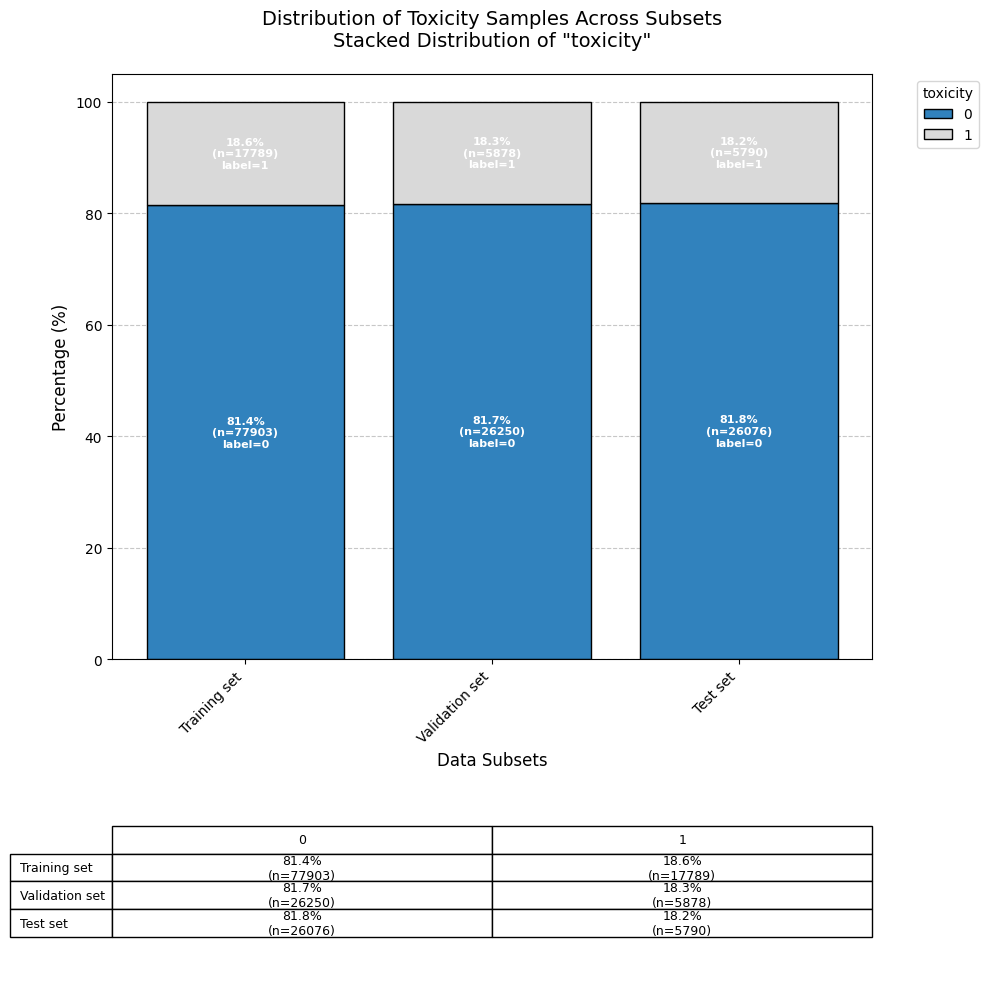

In [ ]:
plot_column_distribution_stacked('toxicity', [toxicity_train_set, toxicity_val_set, toxicity_test_set], 'Distribution of Toxicity Samples Across Subsets', ["Training set", "Validation set", "Test set"])

### Emotion Preprocessing

In [ ]:
# Cleanse and compute the tokens of the texts inside the combined dataframe
emotion_combined_df['cleaned_comment'] = emotion_combined_df['comments'].apply(clean_text)
emotion_combined_df['tokens'] = emotion_combined_df['cleaned_comment'].apply(cleaner_function)
emotion_combined_df

,comments,emotion,split,emotion_encoded,cleaned_comment,tokens
0,i didnt feel humiliated,sadness,train,4,i didnt feel humiliated,"[i, didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,sadness,train,4,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feeling, so, hopeless, to, ..."
2,im grabbing a minute to post i feel greedy wrong,anger,train,0,im grabbing a minute to post i feel greedy wrong,"[im, grabbing, a, minute, to, post, i, feel, g..."
3,i am ever feeling nostalgic about the fireplac...,love,train,3,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feeling, nostalgic, about, the, ..."
4,i am feeling grouchy,anger,train,0,i am feeling grouchy,"[i, am, feeling, grouchy]"
...,...,...,...,...,...,...
19995,i just keep feeling like someone is being unki...,anger,test,0,i just keep feeling like someone is being unki...,"[i, just, keep, feeling, like, someone, is, be..."
19996,im feeling a little cranky negative after this...,anger,test,0,im feeling a little cranky negative after this...,"[im, feeling, a, little, cranky, negative, aft..."
19997,i feel that i am useful to my people and that ...,joy,test,2,i feel that i am useful to my people and that ...,"[i, feel, that, i, am, useful, to, my, people,..."
19998,im feeling more comfortable with derby i feel ...,joy,test,2,im feeling more comfortable with derby i feel ...,"[im, feeling, more, comfortable, with, derby, ..."


In [ ]:
emotion_train_set = emotion_combined_df[emotion_combined_df['split'] == 'train'].drop(columns=['split'])
emotion_val_set   = emotion_combined_df[emotion_combined_df['split'] == 'val'].drop(columns=['split'])
emotion_test_set  = emotion_combined_df[emotion_combined_df['split'] == 'test'].drop(columns=['split'])

emotion_train_set

,comments,emotion,emotion_encoded,cleaned_comment,tokens
0,i didnt feel humiliated,sadness,4,i didnt feel humiliated,"[i, didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,sadness,4,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feeling, so, hopeless, to, ..."
2,im grabbing a minute to post i feel greedy wrong,anger,0,im grabbing a minute to post i feel greedy wrong,"[im, grabbing, a, minute, to, post, i, feel, g..."
3,i am ever feeling nostalgic about the fireplac...,love,3,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feeling, nostalgic, about, the, ..."
4,i am feeling grouchy,anger,0,i am feeling grouchy,"[i, am, feeling, grouchy]"
...,...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,4,i just had a very brief time in the beanbag an...,"[i, just, had, a, very, brief, time, in, the, ..."
15996,i am now turning and i feel pathetic that i am...,sadness,4,i am now turning and i feel pathetic that i am...,"[i, am, now, turning, and, i, feel, pathetic, ..."
15997,i feel strong and good overall,joy,2,i feel strong and good overall,"[i, feel, strong, and, good, overall]"
15998,i feel like this was such a rude comment and i...,anger,0,i feel like this was such a rude comment and i...,"[i, feel, like, this, wa, such, a, rude, comme..."


In [ ]:
print('\033[92mtraining set size:', len(emotion_train_set), ', percentage:', len(emotion_train_set) * 100 / len(emotion_combined_df))
print('validation set size:', len(emotion_val_set), ', percentage:', len(emotion_val_set) * 100 / len(emotion_combined_df))
print('testing set size:', len(emotion_test_set), ', percentage:', len(emotion_test_set) * 100 / len(emotion_combined_df), '\033[0m')

training set size: 16000 , percentage: 80.0
validation set size: 2000 , percentage: 10.0
testing set size: 2000 , percentage: 10.0 


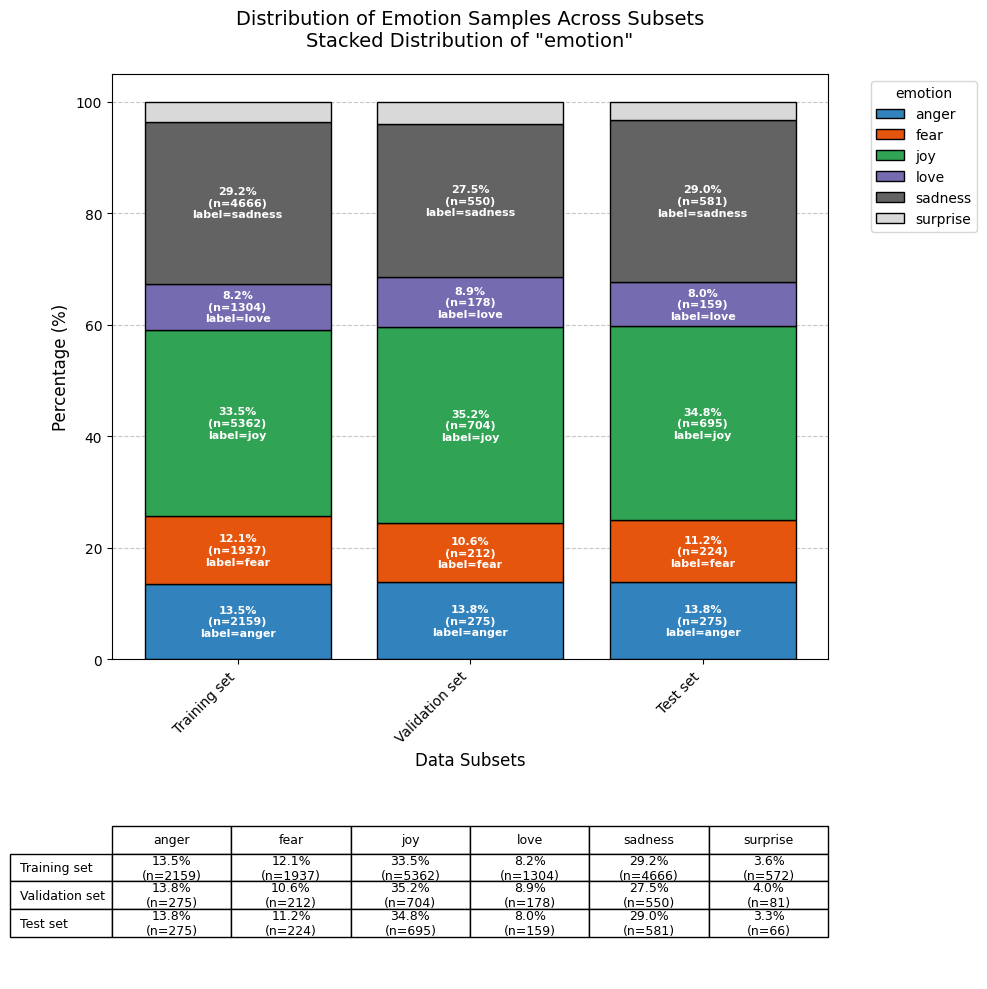

In [ ]:
plot_column_distribution_stacked('emotion', [emotion_train_set, emotion_val_set, emotion_test_set], 'Distribution of Emotion Samples Across Subsets', ["Training set", "Validation set", "Test set"])

### Sarcasm Preprocessing

In [ ]:
# splits the sarcasm dataframe into train, test, val datasets
def train_test_val_split(dataframe):
  positive_set = dataframe[dataframe['sarcastic'] == 1]
  negative_set = dataframe[dataframe['sarcastic'] == 0]

  train_positive_subset = positive_set[positive_set['split'] == 'train'].sample(57000, random_state=42)
  train_negative_subset = negative_set[negative_set['split'] == 'train'].sample(57000, random_state=42)
  test_positive_subset = positive_set[positive_set['split'] == 'test'].sample(24160, random_state=42)
  test_negative_subset = negative_set[negative_set['split'] == 'test'].sample(24160, random_state=42)
  train_set = pd.concat([train_positive_subset, train_negative_subset], ignore_index=True)
  test_set = pd.concat([test_positive_subset, test_negative_subset], ignore_index=True)

  train_set = train_set.drop(columns=['split'])
  test_set = test_set.drop(columns=['split'])
  train_set, val_set = train_test_split(train_set, test_size=0.1, random_state=42)

  return train_set, test_set, val_set

In [ ]:
sarcasm_df['cleaned_comment'] = sarcasm_df['text'].apply(clean_text)
sarcasm_df['tokens'] = sarcasm_df['cleaned_comment'].apply(cleaner_function)
sarcasm_train_set, sarcasm_test_set, sarcasm_val_set = train_test_val_split(sarcasm_df)

sarcasm_train_set

,id,author,text,sarcastic,cleaned_comment,tokens
60968,d5b22r9,Basdad,"As it should be, it is out of respect for thei...",0,"as it should be, it is out of respect for thei...","[a, it, should, be, it, is, out, of, respect, ..."
67817,cyp7gvi,SciFiCahill,Odd that comments are disabled on the YouTube ...,0,odd that comments are disabled on the youtube ...,"[odd, that, comment, are, disabled, on, the, y..."
9749,dbiszap,Justinw303,Interesting discovery!,1,interesting discovery!,"[interesting, discovery]"
13948,dfynhpc,Borisisagreatname,"Well, at least it wasn't lying on the floor",1,"well, at least it wasn't lying on the floor","[well, at, least, it, wa, n't, lying, on, the,..."
49568,c820b1u,Diogenes33,The free market will fix it.,1,the free market will fix it.,"[the, free, market, will, fix, it]"
...,...,...,...,...,...,...
76820,d2bcde1,tramadolic,Horrible nasty smurf..( cool poster tho ).,0,horrible nasty smurf..( cool poster tho ).,"[horrible, nasty, smurf, .., cool, poster, tho]"
110268,dbx6vpa,The_DriveBy,"You spelled ""stunt double"" wrong.",0,"you spelled ""stunt double"" wrong.","[you, spelled, ``, stunt, double, '', wrong]"
103694,d305fsn,mrrooroo,Damn they're some poor pilots in the U.S of A!,0,damn they're some poor pilots in the u.s of a!,"[damn, they, 're, some, poor, pilot, in, the, ..."
860,cpszmkv,Pugs501,Linus should do a Retro Review on this,1,linus should do a retro review on this,"[linus, should, do, a, retro, review, on, this]"


In [ ]:
sarcasm_final_total = len(sarcasm_train_set) + len(sarcasm_val_set) + len(sarcasm_test_set)
print('\033[92mtraining set size:', len(sarcasm_train_set), ', percentage:', len(sarcasm_train_set) * 100 / sarcasm_final_total)
print('validation set size:', len(sarcasm_val_set), ', percentage:', len(sarcasm_val_set) * 100 / sarcasm_final_total)
print('testing set size:', len(sarcasm_test_set), ', percentage:', len(sarcasm_test_set) * 100 / sarcasm_final_total, '\033[0m')

training set size: 102600 , percentage: 63.20847708230656
validation set size: 11400 , percentage: 7.023164120256284
testing set size: 48320 , percentage: 29.768358797437163 


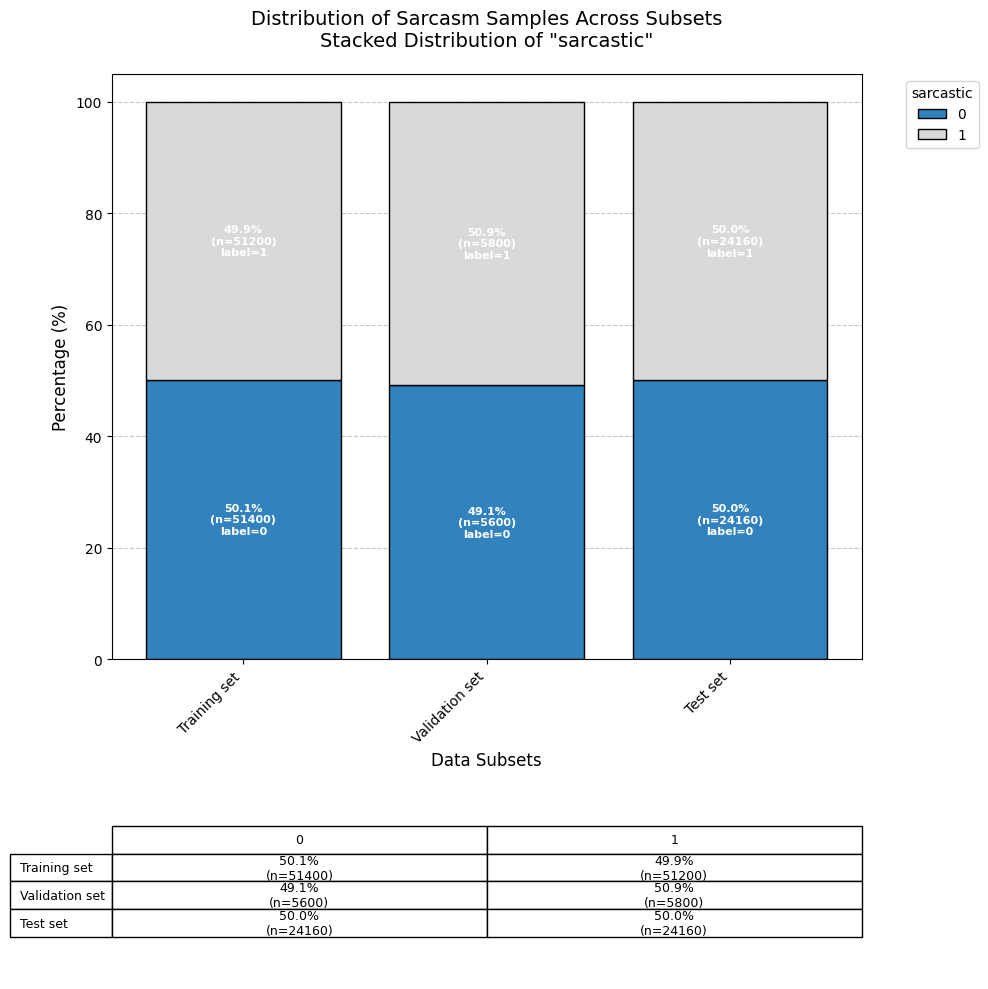

In [ ]:
plot_column_distribution_stacked('sarcastic', [sarcasm_train_set, sarcasm_val_set, sarcasm_test_set], 'Distribution of Sarcasm Samples Across Subsets', ["Training set", "Validation set", "Test set"])

## *Model Creation*

We have already split up the different datasets into 3 distinct subsets, training, validation, and testing.

The next rest of the code is located within a function so that we can easily perform the training process on different subsets on the data.

In [ ]:
EMOTION_FILE_NAME = 'emotion_classification_model.keras'
SARCASM_FILE_NAME = 'sarcasm_classification_model.keras'
TOXICITY_FILE_NAME = 'toxicity_classification_model.keras'
UNIFIED_WORD2VEC_PATH = 'unified_word2vec_vectors.kv'

### Word2Vec

Create a unified word2vec model to ensure that the different models can talk to each other even if they're using different datasets.

This is the pretrained embeddings model, storing vectors for words. Each word in the vocabulary has a corresponding vector.

In [ ]:
unified_dataframe = pd.concat([toxicity_train_set, toxicity_test_set, toxicity_val_set, sarcasm_train_set, sarcasm_test_set, sarcasm_val_set, emotion_train_set, emotion_test_set, emotion_val_set], ignore_index=True)
unified_dataframe.head()
unified_tokenized_sentences = unified_dataframe['tokens'].tolist()

# Create unified word2vec model
print('\033[92mcreating unified word2vec embedding model\033[0m')
unified_embedding_model = word2vec.Word2Vec(unified_tokenized_sentences, vector_size=128, window=10, min_count=5)
unified_embedding_model.wv.save(UNIFIED_WORD2VEC_PATH)
print('\033[92munified word embeddings completed and saved\033[0m')

creating unified word2vec embedding model
unified word embeddings completed and saved


In [ ]:
# embedding_model out the word2vec model
unified_embedding_model.wv.most_similar('king')

[('prince', 0.818325400352478),
 ('emperor', 0.7825872898101807),
 ('henry', 0.7557928562164307),
 ('raja', 0.7492956519126892),
 ('chalukya', 0.7352747917175293),
 ('earl', 0.715534508228302),
 ('lord', 0.7118962407112122),
 ('princess', 0.7079625725746155),
 ('duke', 0.7063820958137512),
 ('sultan', 0.7041824460029602)]

## Create Keras Tokenizer

Use keras tokenized to convert text to sequences of indices matchhing our embedding matrix. This is just a preprocesing tool, scanning the text in the comments and assigning it with integer indices.

It converts words in a sentence to a sequence of indices for downstream Keras models.

In [ ]:
unified_keras_tokenizer_input = unified_dataframe['cleaned_comment'].tolist()
unified_keras_tokenizer = Tokenizer()

# Need to make sure that word_index matches the Word2Vec vocabulary
w2v_vocab = set(unified_embedding_model.wv.key_to_index.keys())
unified_keras_tokenizer.fit_on_texts([[word] for word in w2v_vocab])

### Create unified embedding matrix

The Keras embedding layer requires a matrix of shape (vocab_size and embedding_dim). This converts from the word2vec model to the indices that keras created.

In [ ]:
vocab = unified_embedding_model.wv.key_to_index  # dictionary mapping word -> index
vocab_size = len(vocab) + 1

unified_embedding_dim = unified_embedding_model.vector_size

# Create an embedding matrix
unified_embedding_matrix = np.zeros((vocab_size, unified_embedding_dim))  # +1 for padding index 0
for word, i in vocab.items():
    embedding_vector = unified_embedding_model.wv[word]
    if embedding_vector is not None:
        unified_embedding_matrix[i] = embedding_vector

### Emotion Classification Model

In [ ]:
# this class represents an emotion model, providing useful methods for downstream tasks
SEQUENCE_PADDING_MAXLEN=50

SharedInputLayer = Input(shape=(SEQUENCE_PADDING_MAXLEN,))
SharedEmbeddingLayer = Embedding(
    input_dim=vocab_size,
    output_dim=unified_embedding_dim,
    weights=[unified_embedding_matrix],
    trainable=True # We want these to be trainable
)(SharedInputLayer)

class EmotionModel:
  def __init__(self, X, y):
    self.X = X
    self.y = tf.keras.utils.to_categorical(y, num_classes=6) if y is not None else None
    self.model = self._create_model()

  def _create_model(self):
    global SharedEmbeddingLayer
    global SharedInputLayer

    layers = SpatialDropout1D(0.5)(SharedEmbeddingLayer)
    layers = LSTM(128, recurrent_dropout=0.5, dropout=0.5, return_sequences=True)(layers)
    layers = Conv1D(filters=128, kernel_size=10, activation='relu', strides=3)(layers)
    layers = Dropout(0.5)(layers)
    layers = LSTM(128, recurrent_dropout=0.5, dropout=0.5, return_sequences=True)(layers)
    layers = Conv1D(filters=128, kernel_size=10, activation='relu', strides=3)(layers)
    layers = GlobalMaxPooling1D()(layers)
    output = Dense(6, activation='softmax')(layers)

    return Model(inputs=SharedInputLayer, outputs=output, name='Emotion_Classification_Model')

  def compile(self):
    self.model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')])
    self.model.summary()

  def train(self, Xy_val=None, epochs=10, batch_size=128):
    checkpoint = ModelCheckpoint(EMOTION_FILE_NAME, verbose=1, save_best_only=True, mode='min')
    earlystopping = EarlyStopping(patience=5, verbose=1, restore_best_weights=True)

    dataset = Dataset.from_tensor_slices((self.X, self.y))
    dataset = (dataset.cache().shuffle(buffer_size=len(emotion_train_set)).batch(batch_size).prefetch(tf.data.AUTOTUNE))

    return self.model.fit(dataset, validation_data=Xy_val, epochs=epochs, callbacks=[checkpoint, earlystopping])

In [ ]:
# Helper method for creating the emotion model from a subset of the data
def create_emotion_model(subset_dataframe):
  tokenized_sentences = subset_dataframe["cleaned_comment"].to_list()
  labels = subset_dataframe["emotion_encoded"].values

  sequences = unified_keras_tokenizer.texts_to_sequences(tokenized_sentences)
  X = pad_sequences(sequences, maxlen=SEQUENCE_PADDING_MAXLEN, padding='post', truncating='post')
  y = np.array(labels)

  return EmotionModel(X, y)

In [ ]:
emotion_model = create_emotion_model(emotion_train_set)
emotion_model.compile()

Model: "Emotion_Classification_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 50, 128)        │     5,729,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 50, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 14, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 14, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 128)         │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,320,902 (24.11 MB)

 Trainable params: 6,320,902 (24.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# create and prepare the validation data
def create_emotion_validation():
  tokenized_sentences = emotion_val_set['tokens'].to_list()
  labels = emotion_val_set['emotion_encoded'].values

  sequences = unified_keras_tokenizer.texts_to_sequences(tokenized_sentences)
  X_val = pad_sequences(sequences, maxlen=SEQUENCE_PADDING_MAXLEN, padding='post', truncating='post')
  y_val = tf.keras.utils.to_categorical(labels, num_classes=6) # convert the labels to one hot encoded vectors

  val_set = Dataset.from_tensor_slices((X_val, y_val))
  val_set = (val_set.cache().batch(512).prefetch(tf.data.AUTOTUNE))

  return val_set

emotion_validation_dataset = create_emotion_validation()

In [ ]:
emotion_model_history = emotion_model.train(Xy_val=emotion_validation_dataset, epochs=50, batch_size=1024)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.2920 - f1_score: 0.1438 - loss: 1.6581 - precision: 0.2700 - recall: 0.0049
Epoch 1: val_loss improved from inf to 1.59087, saving model to emotion_classification_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 321ms/step - accuracy: 0.2937 - f1_score: 0.1436 - loss: 1.6558 - precision: 0.2730 - recall: 0.0048 - val_accuracy: 0.3370 - val_f1_score: 0.1321 - val_loss: 1.5909 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.3319 - f1_score: 0.1250 - loss: 1.5839 - precision: 0.1972 - recall: 9.5880e-05
Epoch 2: val_loss improved from 1.59087 to 1.58850, saving model to emotion_classification_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 334ms/step - accuracy: 0.3322 - f1_score: 0.1250 - loss: 1.5837 - precision: 0.2108 - recall: 1.0127e-04 - val_accuracy: 0.3260 - val_f1_score: 0.1324 - val_loss: 1.5885 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3

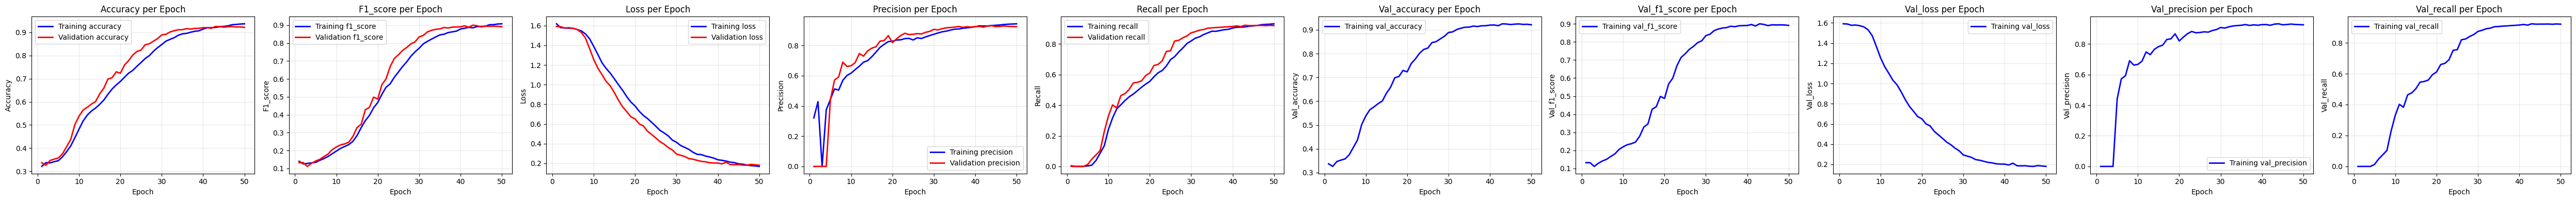

In [ ]:
# Print the training history of the emotional classification model
plot_training_history(emotion_model_history)

In [ ]:
# Loading the emotional model from a file
from tensorflow.keras.models import load_model
emotion_model_goldsrc = load_model(EMOTION_FILE_NAME)
emotion_model_goldsrc.summary()

Model: "Emotion_Classification_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 50, 128)        │     5,729,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 50, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 14, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 14, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 128)         │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,962,708 (72.34 MB)

 Trainable params: 6,320,902 (24.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,641,806 (48.22 MB)

### Testing the performance of the Emotional Classification Model

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step


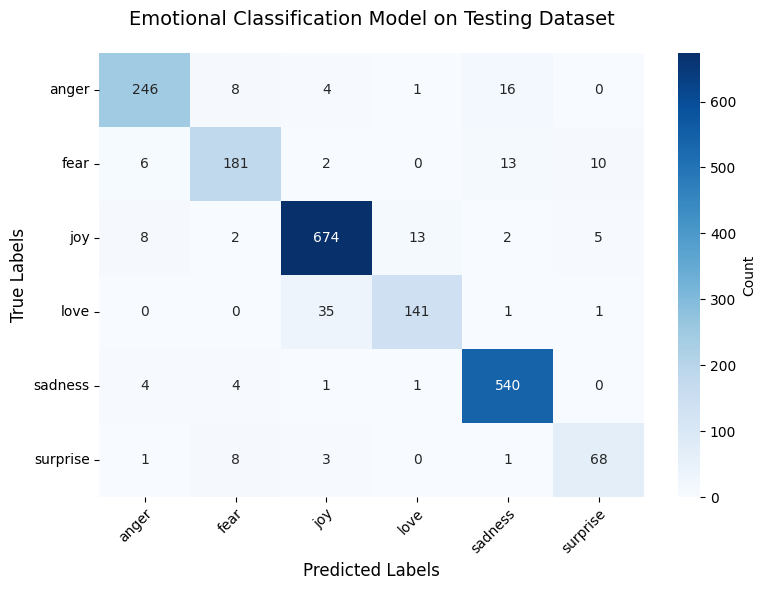

Accuracy: 0.9250
Precision: 0.9022
Recall: 0.8865
F1 Score: 0.8935


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Check the performance of the emotional analysis model on emotion_validation_dataset
def test_emotional_model():
  tokenized_sentences = emotion_val_set['tokens'].to_list()
  labels = emotion_val_set['emotion_encoded'].values

  sequences = unified_keras_tokenizer.texts_to_sequences(tokenized_sentences)
  X_val = pad_sequences(sequences, maxlen=SEQUENCE_PADDING_MAXLEN, padding='post', truncating='post')

  model_predictions = emotion_model.model.predict(X_val)
  pred_labels = [np.argmax(output) for output in model_predictions]

  emotion_dict = { 'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5 }
  reverse_emotion_dict = {v: k for k, v in emotion_dict.items()}

  plot_confusion_matrix(
      [reverse_emotion_dict[num] for num in pred_labels], [reverse_emotion_dict[num] for num in labels],
      title="Emotional Classification Model on Testing Dataset"
                        )

  accuracy = accuracy_score(labels, pred_labels)
  precision = precision_score(labels, pred_labels, average='macro')
  recall = recall_score(labels, pred_labels, average='macro')
  f1 = f1_score(labels, pred_labels, average='macro')

  # Print all metrics
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1 Score: {f1:.4f}")

test_emotional_model()

---

### Sarcasm Model

In [ ]:
# create layer with multihead-attention block
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable(package="Custom")
class SelfAttentionBlock(Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super().__init__()
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.attn = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
        self.norm = LayerNormalization()

    def build(self, input_shape):
        super().build(input_shape)

    def call(self, x):
        attn_out = self.attn(x, x)
        return self.norm(x + attn_out)  # residual + norm

    def get_config(self):
      config = super().get_config()
      config.update({'num_heads': self.num_heads, 'key_dim': self.key_dim})

      return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [ ]:
# this class represents an sarcasm model, providing useful methods for downstream tasks
class SarcasmModel:
  def __init__(self, X, y):
    self.X = X
    self.y = tf.keras.utils.to_categorical(y, num_classes=2) if y is not None else None
    self.model = self._create_model()

  def _create_model(self):
    global SharedEmbeddingLayer
    global SharedInputLayer

    layers = Bidirectional(LSTM(200, dropout=0, return_sequences=True))(SharedEmbeddingLayer)
    layers = SelfAttentionBlock(num_heads=10, key_dim=64)(layers)
    layers = Bidirectional(LSTM(200, dropout=0, return_sequences=True))(layers)
    layers = GlobalAveragePooling1D()(layers)
    layers = Dense(200, activation='relu')(layers)
    output = Dense(2, activation='softmax')(layers)

    return Model(inputs=SharedInputLayer, outputs=output, name='Sarcasm_Classification_Model')

  def compile(self):
    self.model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')])
    self.model.summary()

  def train(self, Xy_val=None, epochs=10, batch_size=128):
    checkpoint = ModelCheckpoint(SARCASM_FILE_NAME, monitor='val_loss', verbose=1,save_best_only=True, mode='min')
    earlystopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)

    dataset = Dataset.from_tensor_slices((self.X, self.y))
    dataset = (dataset.cache().shuffle(buffer_size=len(sarcasm_train_set)).batch(batch_size).prefetch(tf.data.AUTOTUNE))

    return self.model.fit(dataset, validation_data=Xy_val, epochs=epochs, callbacks=[checkpoint, earlystopping])

  def inference(self, new_texts):
    new_sequences = self.sequencer.tokens_to_sequences(new_texts)
    new_padded = pad_sequences(new_sequences, maxlen=self.max_len, padding='post', truncating='post')
    pred_probs = self.model.predict(new_padded)
    pred_labels = (pred_probs > 0.5).astype(int)

    return new_texts, pred_probs, pred_labels

In [ ]:
# Helper method for creating the sarcasm model from a subset of the data
def create_sarcasm_model(subset_dataframe):
  tokenized_sentences = subset_dataframe["tokens"].to_list()
  labels = subset_dataframe["sarcastic"].values

  sequences = unified_keras_tokenizer.texts_to_sequences(tokenized_sentences)
  X = pad_sequences(sequences, maxlen=SEQUENCE_PADDING_MAXLEN, padding='post', truncating='post')
  y = np.array(labels)

  return SarcasmModel(X, y)

In [ ]:
sarcasm_model = create_sarcasm_model(sarcasm_train_set)
sarcasm_model.compile()

Model: "Sarcasm_Classification_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 50, 128)        │     5,729,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 400)        │       526,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention_block            │ (None, 50, 400)        │     1,027,120 │
│ (SelfAttentionBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 50, 400)        │       961,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 400)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           402 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,324,746 (31.76 MB)

 Trainable params: 8,324,746 (31.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# create and prepare the validation data
def create_sarcasm_validation():
  tokenized_sentences = sarcasm_val_set["tokens"].to_list()
  labels = sarcasm_val_set["sarcastic"].values

  sequences = unified_keras_tokenizer.texts_to_sequences(tokenized_sentences)
  X_val = pad_sequences(sequences, maxlen=SEQUENCE_PADDING_MAXLEN, padding='post', truncating='post')
  y_val = tf.keras.utils.to_categorical(np.array(labels), num_classes=2)

  val_set = Dataset.from_tensor_slices((X_val, y_val))
  val_set = (val_set.cache().shuffle(buffer_size=len(sarcasm_val_set)).batch(2048).prefetch(tf.data.AUTOTUNE))

  return val_set

sarcasm_validation_dataset = create_sarcasm_validation()
sarcasm_validation_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 50), dtype=tf.int32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float64, name=None))>

In [ ]:
tf.keras.backend.clear_session()
sarcasm_model_history = sarcasm_model.train(Xy_val=sarcasm_validation_dataset, epochs=30, batch_size=2048)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.5224 - f1_score: 0.5179 - loss: 0.7800 - precision: 0.5224 - recall: 0.5224
Epoch 1: val_loss improved from inf to 0.63006, saving model to sarcasm_classification_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5232 - f1_score: 0.5188 - loss: 0.7784 - precision: 0.5232 - recall: 0.5232 - val_accuracy: 0.6439 - val_f1_score: 0.6436 - val_loss: 0.6301 - val_precision: 0.6439 - val_recall: 0.6439
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.7206 - f1_score: 0.7203 - loss: 0.5519 - precision: 0.7206 - recall: 0.7206
Epoch 2: val_loss did not improve from 0.63006
51/51 ━━━━━━━━━━━━━━━━━━━━ 49s 964ms/step - accuracy: 0.7209 - f1_score: 0.7206 - loss: 0.5515 - precision: 0.7209 - recall: 0.7209 - val_accuracy: 0.6428 - val_f1_score: 0.6385 - val_loss: 0.6827 - val_precision: 0.6428 - val_recall: 0.6428
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 941ms/step - accuracy: 0.7930 - f1_score: 0.7929

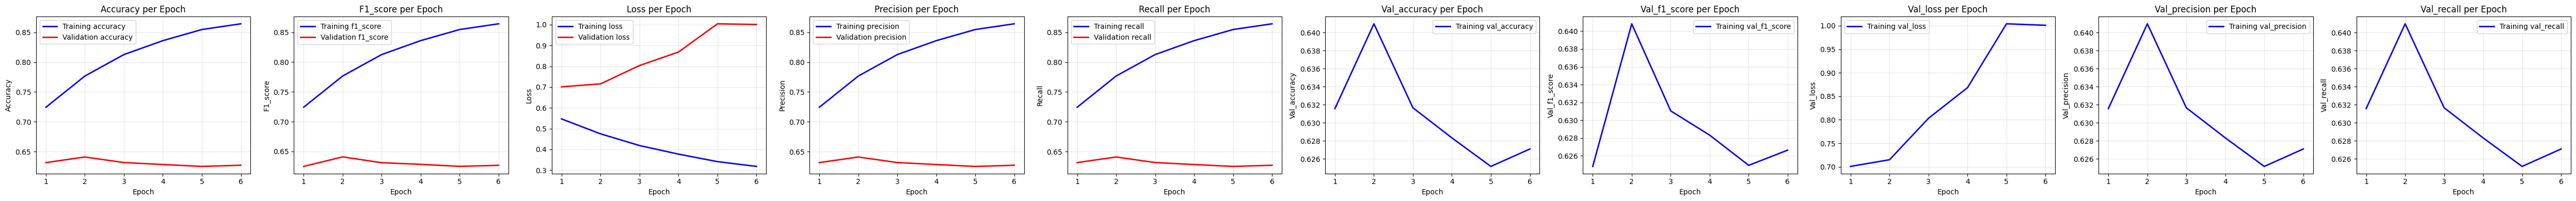

In [ ]:
# Print the training history of the sarcasm classification model
plot_training_history(sarcasm_model_history)

In [ ]:
sarcasm_model.model.save(SARCASM_FILE_NAME)

## Testing the performance of the satisfaction classification model

1510/1510 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step


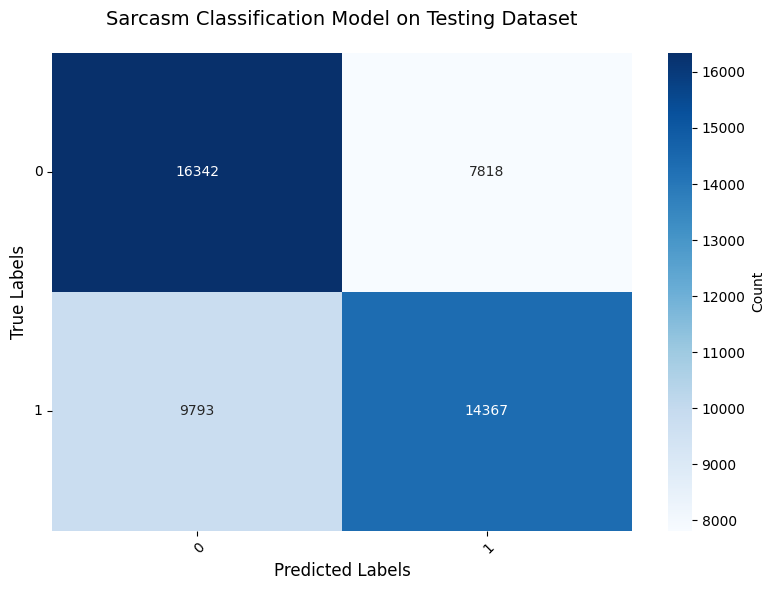

Accuracy: 0.6355
Precision: 0.6364
Recall: 0.6355
F1 Score: 0.6349


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Check the performance of the sarcasm analysis model on sarcasm_validation_dataset
def test_sarcasm_model():
  tokenized_sentences = sarcasm_test_set['tokens'].to_list()
  labels = sarcasm_test_set['sarcastic'].values

  sequences = unified_keras_tokenizer.texts_to_sequences(tokenized_sentences)
  X_val = pad_sequences(sequences, maxlen=SEQUENCE_PADDING_MAXLEN, padding='post', truncating='post')

  model_predictions = sarcasm_model.model.predict(X_val)
  pred_labels = [np.argmax(output) for output in model_predictions]

  plot_confusion_matrix(
      pred_labels, labels,
      title="Sarcasm Classification Model on Testing Dataset"
                        )

  accuracy = accuracy_score(labels, pred_labels)
  precision = precision_score(labels, pred_labels, average='macro')
  recall = recall_score(labels, pred_labels, average='macro')
  f1 = f1_score(labels, pred_labels, average='macro')

  # Print all metrics
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1 Score: {f1:.4f}")

test_sarcasm_model()

### Ensemble Model

In [ ]:
def load_models():
  emotion_embeddings = KeyedVectors.load('emotion_word2vec_vectors.kv')
  sarcasm_embeddings = KeyedVectors.load_word2vec_format('glove_100d.txt', no_header=True, binary=False)
  loaded_emotion_model = EmotionModel(emotion_embeddings, Sequencer(emotion_embeddings), 50, None, None)
  loaded_sarcasm_model = SarcasmModel(sarcasm_embeddings, Sequencer(sarcasm_embeddings), 50, None, None)
  loaded_emotion_model.model = load_model(EMOTION_FILE_NAME)

  with custom_object_scope({'SelfAttentionBlock': SelfAttentionBlock}):
    loaded_sarcasm_model.model = load_model(SARCASM_FILE_NAME)

  # set trainability of the models to false except for embeddings
  for layer in loaded_emotion_model.model.layers:
    if layer.__class__.__name__ != 'Embedding':
      layer.trainable = False

  for layer in loaded_sarcasm_model.model.layers:
    if layer.__class__.__name__ != 'Embedding':
      layer.trainable = False

  return loaded_emotion_model, loaded_sarcasm_model

In [ ]:
CAN_FINETUNE = True

# this class represents the toxicity model, providing useful methods for downstream tasks
class Toxicity_Model:
  def __init__(self, emotion_model, sarcasm_model):
    self.emotion_model = emotion_model
    self.sarcasm_model = sarcasm_model
    self.model = self._create_model()

  def _create_model(self):
    emotion_input = Input(shape=(50,))
    sarcasm_input = Input(shape=(50,))
    emotion_output = self.emotion_model.model(emotion_input)
    sarcasm_output = self.sarcasm_model.model(sarcasm_input)

    merged_layer = Concatenate()([emotion_output, sarcasm_output])
    merged_layer = Dense(64, activation='relu')(merged_layer)
    output = Dense(1, activation='sigmoid')(merged_layer)

    return Model(inputs=[emotion_input, sarcasm_input], outputs=output, name='Toxicity_Classification_Ensemble_Model')

  def compile(self):
    self.model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')])
    self.model.summary()

  def train(self, Xy_val=None, epochs=10, batch_size=128):
    self.emotion_model.trainable = CAN_FINETUNE
    self.sarcasm_model.trainable = CAN_FINETUNE

    checkpoint = ModelCheckpoint(TOXICITY_FILE_NAME, verbose=1, save_best_only=True, mode='min' )
    earlystopping = EarlyStopping(patience=5, verbose=1, restore_best_weights=True)

    tokenized_sentences = toxicity_train_set["tokens"].to_list()
    labels = toxicity_train_set["toxicity"].values

    sequences = unified_keras_tokenizer.texts_to_sequences(tokenized_sentences)
    X_val = pad_sequences(sequences, maxlen=SEQUENCE_PADDING_MAXLEN, padding='post', truncating='post')

    y = np.array(labels).reshape(-1, 1)
    dataset = Dataset.from_tensor_slices(((X_val, X_val), y))
    dataset = (dataset.cache().shuffle(buffer_size=len(toxicity_train_set)).batch(batch_size).prefetch(tf.data.AUTOTUNE))

    return self.model.fit(dataset, validation_data=Xy_val, epochs=epochs, callbacks=[checkpoint, earlystopping])

  # array of text for model predictions
  def inference(self, texts):
    tokenized_sentences = [word_tokenize(text) for text in texts]
    emo_x, sarc_x = self.pad_sequences(tokenized_sentences)

    return self.model.predict([emo_x, sarc_x], verbose=0)

In [ ]:
def create_toxicity_validation(tox_model):
  tokenized_sentences = toxicity_val_set['tokens'].to_list()
  labels = toxicity_val_set['toxicity'].values

  sequences = unified_keras_tokenizer.texts_to_sequences(tokenized_sentences)
  X_val = pad_sequences(sequences, maxlen=SEQUENCE_PADDING_MAXLEN, padding='post', truncating='post')

  y_val = np.array(labels).reshape(-1, 1)
  val_set = Dataset.from_tensor_slices(((X_val, X_val), y_val))
  val_set = (val_set.cache().batch(512).prefetch(tf.data.AUTOTUNE))

  return val_set

In [ ]:
# loaded_emotion_model, loaded_sarcasm_model = load_models()
toxicity_model = Toxicity_Model(emotion_model, sarcasm_model)
toxicity_model.compile()

Model: "Toxicity_Classification_Ensemble_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Emotion_Classifica… │ (None, 6)         │  6,320,902 │ input_layer_4[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Sarcasm_Classifica… │ (None, 2)         │  8,324,746 │ input_layer_5[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8)         │          0 │ Emotion_Classifi… │
│ (Concatenate)       │                   │            │ Sarcasm_Classifi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │        576 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,917,265 (34.02 MB)

 Trainable params: 8,917,265 (34.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
toxicity_validation_dataset = create_toxicity_validation(toxicity_model)
toxicity_model_history = toxicity_model.train(Xy_val=toxicity_validation_dataset, epochs=50)

Epoch 1/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.8162 - f1_score: 0.3176 - loss: 0.4851 - precision: 0.3460 - recall: 0.0553
Epoch 1: val_loss improved from inf to 0.31348, saving model to toxicity_classification_model.keras
748/748 ━━━━━━━━━━━━━━━━━━━━ 218s 275ms/step - accuracy: 0.8162 - f1_score: 0.3176 - loss: 0.4850 - precision: 0.3465 - recall: 0.0554 - val_accuracy: 0.8831 - val_f1_score: 0.3093 - val_loss: 0.3135 - val_precision: 0.8379 - val_recall: 0.4476
Epoch 2/50
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.8752 - f1_score: 0.3142 - loss: 0.3198 - precision: 0.7813 - recall: 0.4590
Epoch 2: val_loss improved from 0.31348 to 0.26926, saving model to toxicity_classification_model.keras
748/748 ━━━━━━━━━━━━━━━━━━━━ 210s 280ms/step - accuracy: 0.8752 - f1_score: 0.3142 - loss: 0.3198 - precision: 0.7813 - recall: 0.4591 - val_accuracy: 0.8987 - val_f1_score: 0.3093 - val_loss: 0.2693 - val_precision: 0.8831 - val_recall: 0.5143
Epoch 3/50
748/748

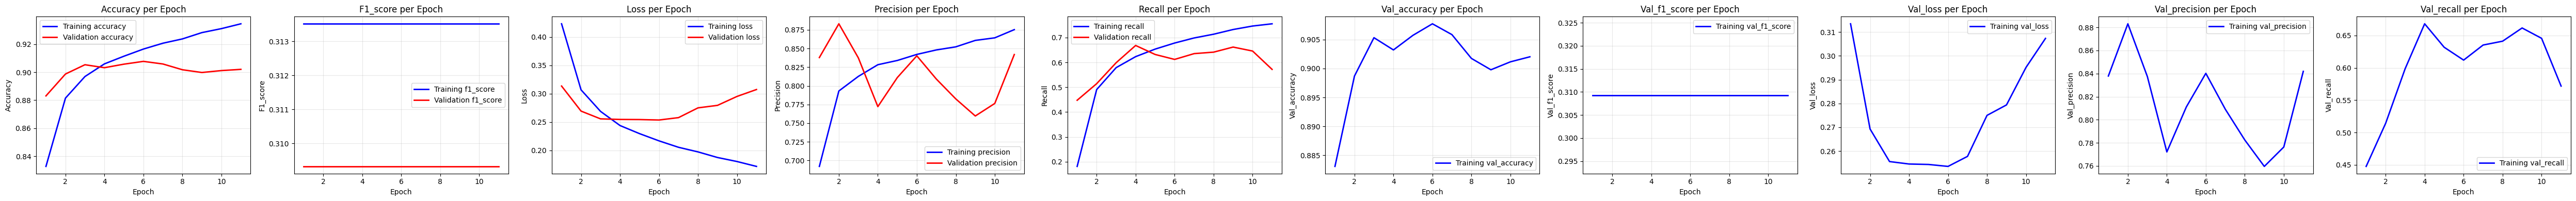

In [ ]:
# Print the training history of the toxicity classification model
plot_training_history(toxicity_model_history)

In [ ]:
toxicity_model.model.save(TOXICITY_FILE_NAME)

## Evaluation of the completed EmoTox model

In [ ]:
# Loading the toxicity model from a file
from tensorflow.keras.models import load_model

emotional_model_goldsrc = load_model(EMOTION_FILE_NAME)
sarcasm_model_goldsrc = load_model(SARCASM_FILE_NAME, custom_objects=dict(SelfAttentionBlock=SelfAttentionBlock),)
toxicity_model_goldsrc = load_model(TOXICITY_FILE_NAME, custom_objects=dict(SelfAttentionBlock=SelfAttentionBlock),)
toxicity_model_goldsrc.summary()

ValueError: A total of 1 objects could not be loaded. Example error message for object <Embedding name=embedding_2, built=True>:

Layer 'embedding_2' expected 1 variables, but received 0 variables during loading. Expected: ['embeddings']

List of objects that could not be loaded:
[<Embedding name=embedding_2, built=True>]

## Run predictions using the trained model on the Toxicity Testing Subset

In [ ]:
def run_toxicity_prediction_on_test_set():
  tokenized_sentences = toxicity_test_set["tokens"].to_list()
  sequences = unified_keras_tokenizer.texts_to_sequences(tokenized_sentences)
  X_val = pad_sequences(sequences, maxlen=SEQUENCE_PADDING_MAXLEN, padding='post', truncating='post')

  predictions = toxicity_model.model.predict([X_val, X_val], verbose=0)
  flattened_predictions = predictions.flatten()

  return flattened_predictions

def run_toxicity_prediction(comment):
  sequences = unified_keras_tokenizer.texts_to_sequences(cleaner_function(clean_text(comment)))
  X_val = pad_sequences(sequences, maxlen=SEQUENCE_PADDING_MAXLEN, padding='post', truncating='post')

  return toxicity_model.model.predict([X_val, X_val], verbose=0).flatten()

In [ ]:
toxicity_test_set["prediction"] = run_toxicity_prediction_on_test_set()

/tmp/ipython-input-1121271519.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toxicity_test_set["prediction"] = run_toxicity_prediction_on_test_set()


In [ ]:
toxicity_test_set.to_csv("/content/drive/MyDrive/toxicity_test_set_with_predictions_modified.csv")
toxicity_test_set

,rev_id,comment,split,toxicity,cleaned_comment,tokens,prediction
2,8953.0,Elected or Electoral? JHK,test,0,elected or electoral? jhk,"[elected, or, electoral, jhk]",0.042339
4,28959.0,Please relate the ozone hole to increases in c...,test,0,please relate the ozone hole to increases in c...,"[please, relate, the, ozone, hole, to, increas...",0.008505
19,138074.0,`NEWLINE_TOKENNEWLINE_TOKENNEWLINE_TOKENNEWLIN...,test,0,. . . . i'm not sure if it's properly called f...,"[i, 'm, not, sure, if, it, 's, properly, calle...",0.008353
33,200664.0,NEWLINE_TOKENNEWLINE_TOKENNEWLINE_TOKEN NEWLIN...,test,0,. . . . thanks on the info on how to move a p...,"[thanks, on, the, info, on, how, to, move, a, ...",0.007636
37,213105.0,`NEWLINE_TOKENNEWLINE_TOKEN: I should do that ...,test,0,". . i should do that too, i agree, but i've a...","[i, should, do, that, too, i, agree, but, i, '...",0.007643
...,...,...,...,...,...,...,...
159659,699688359.0,NEWLINE_TOKENNEWLINE_TOKEN== These are the fil...,test,0,. . == these are the files on this topic that ...,"[==, these, are, the, file, on, this, topic, t...",0.032166
159661,699698850.0,"NEWLINE_TOKENNEWLINE_TOKENYeah, I realized I c...",test,0,". . yeah, i realized i created a duplicate id....","[yeah, i, realized, i, created, a, duplicate, ...",0.008250
159677,699820699.0,"`NEWLINE_TOKENYes, from the word ``Guci`` or `...",test,0,". yes, from the word guci or puci meaning flas...","[yes, from, the, word, guci, or, puci, meaning...",0.016551
159682,699851288.0,NEWLINE_TOKENNEWLINE_TOKENThe Institute for Hi...,test,0,. . the institute for historical review is a p...,"[the, institute, for, historical, review, is, ...",0.008406


## Find best threshold

Based on the toxicity confidence score, compute the metrics at different thresholds

In [ ]:
def compute_scores(threshold):
  tp = ((toxicity_test_set['toxicity'] == 1) & (toxicity_test_set['prediction'] >= threshold)).sum()
  tn = ((toxicity_test_set['toxicity'] == 0) & (toxicity_test_set['prediction'] < threshold)).sum()
  fp = ((toxicity_test_set['toxicity'] == 0) & (toxicity_test_set['prediction'] >= threshold)).sum()
  fn = ((toxicity_test_set['toxicity'] == 1) & (toxicity_test_set['prediction'] < threshold)).sum()

  accuracy = (tp + tn) / (tp + tn + fp + fn)
  precision = tp / (tp + fp) if (tp + fp) > 0 else 0
  recall = tp / (tp + fn) if (tp + fn) > 0 else 0
  f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

  return tp, tn, fp, fn, accuracy, precision, recall, f1


In [ ]:
confusion_matrix_results = pd.DataFrame(columns=[
    "threshold", "tp", "tn", "fp", "fn",
    "accuracy", "precision", "recall", "f1"
])

for t in range(0, 101):
  threshold = t / 100

  tp, tn, fp, fn, accuracy, precision, recall, f1 = compute_scores(threshold)
  row = pd.DataFrame([{
      "threshold": threshold,
      "tp": tp,
      "tn": tn,
      "fp": fp,
      "fn": fn,
      "accuracy": accuracy,
      "precision": precision,
      "recall": recall,
      "f1": f1
  }])

  confusion_matrix_results = pd.concat([confusion_matrix_results, row], ignore_index=True)

confusion_matrix_results.to_csv("/content/drive/MyDrive/confusion_matrix_results_modified.csv")

/tmp/ipython-input-964592470.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  confusion_matrix_results = pd.concat([confusion_matrix_results, row], ignore_index=True)


In [ ]:
confusion_matrix_results

,threshold,tp,tn,fp,fn,accuracy,precision,recall,f1
0,0.00,5790,0,26076,0,0.181698,0.181698,1.000000,0.307521
1,0.01,5631,10223,15853,159,0.497521,0.262102,0.972539,0.412921
2,0.02,5437,15213,10863,353,0.648026,0.333558,0.939033,0.492259
3,0.03,5339,16856,9220,451,0.696510,0.366715,0.922107,0.524743
4,0.04,5252,18038,8038,538,0.730873,0.395184,0.907081,0.550524
...,...,...,...,...,...,...,...,...,...
96,0.96,2068,26043,33,3722,0.882163,0.984293,0.357168,0.524141
97,0.97,1992,26048,28,3798,0.879935,0.986139,0.344041,0.510115
98,0.98,1848,26057,19,3942,0.875698,0.989823,0.319171,0.482696
99,0.99,1463,26071,5,4327,0.864056,0.996594,0.252677,0.403141


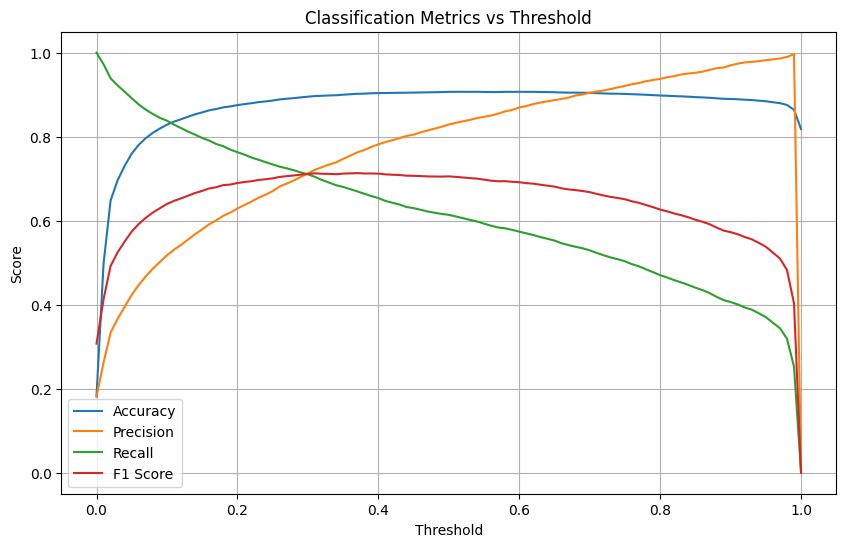

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy, Precision, Recall, F1 vs Threshold
plt.figure(figsize=(10, 6))

plt.plot(confusion_matrix_results["threshold"], confusion_matrix_results["accuracy"], label="Accuracy")
plt.plot(confusion_matrix_results["threshold"], confusion_matrix_results["precision"], label="Precision")
plt.plot(confusion_matrix_results["threshold"], confusion_matrix_results["recall"], label="Recall")
plt.plot(confusion_matrix_results["threshold"], confusion_matrix_results["f1"], label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Classification Metrics vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(confusion_matrix_results["f1"].max())
best_row = confusion_matrix_results.loc[confusion_matrix_results["f1"].idxmax()]
best_row_threshold = best_row["threshold"]

print("here are the results for threshold: " + str(best_row_threshold))
print()

toxicity_test_set['best_predictions'] = ((toxicity_test_set["prediction"] >= best_row_threshold)).astype(int)
mismatches = toxicity_test_set[toxicity_test_set["toxicity"] != toxicity_test_set["best_predictions"]]

0.7133137182787789
here are the results for threshold: 0.37



/tmp/ipython-input-2975919112.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toxicity_test_set['best_predictions'] = ((toxicity_test_set["prediction"] >= best_row_threshold)).astype(int)


In [ ]:
mismatches.to_csv("/content/drive/MyDrive/mismatches_prediction.csv")
mismatches

,rev_id,comment,split,toxicity,cleaned_comment,tokens,prediction,best_predictions
336,2201361.0,NEWLINE_TOKENNEWLINE_TOKENNEWLINE_TOKENNEWLINE...,test,1,. . . . twigs. there are important distinction...,"[twig, there, are, important, distinction, bet...",0.008300,0
394,2615801.0,This is completely ridiculous. The extent to ...,test,0,this is completely ridiculous. the extent to ...,"[this, is, completely, ridiculous, the, extent...",0.860449,1
414,2747887.0,NEWLINE_TOKENNEWLINE_TOKENOh - well - if you p...,test,0,". . oh - well - if you put it that way, all i ...","[oh, well, if, you, put, it, that, way, all, i...",0.375918,1
531,3569538.0,NEWLINE_TOKENNEWLINE_TOKENOpps i made a boo bo...,test,0,. . opps i made a boo boo i dont know what sit...,"[opps, i, made, a, boo, boo, i, dont, know, wh...",0.435813,1
678,4771755.0,`::::: This is fanaticism. I suppose that nex...,test,1,::::: this is fanaticism. i suppose that next...,"[this, is, fanaticism, i, suppose, that, next,...",0.055524,0
...,...,...,...,...,...,...,...,...
159573,699355719.0,`NEWLINE_TOKEN:Thank you. Given the misuse of ...,test,1,. thank you. given the misuse of tools here an...,"[thank, you, given, the, misuse, of, tool, her...",0.053853,0
159575,699358485.0,"NEWLINE_TOKEN::Oh, are you one of this rogue a...",test,1,". :oh, are you one of this rogue admin's littl...","[oh, are, you, one, of, this, rogue, admin, 's...",0.237572,0
159584,699392333.0,NEWLINE_TOKENNEWLINE_TOKEN== Well? ==NEWLINE_T...,test,1,. . == well? ==. . what's wrong with you?,"[==, well, ==, what, 's, wrong, with, you]",0.336890,0
159599,699458324.0,NEWLINE_TOKENNEWLINE_TOKENYou overtly undertak...,test,1,. . you overtly undertake bold indignantly gro...,"[you, overtly, undertake, bold, indignantly, g...",0.363736,0


In [ ]:
matches = toxicity_test_set[toxicity_test_set["toxicity"] == toxicity_test_set["best_predictions"]]
matches.to_csv("/content/drive/MyDrive/matches_prediction.csv")
matches[matches["toxicity"] == 1]

,rev_id,comment,split,toxicity,cleaned_comment,tokens,prediction,best_predictions
82,597212.0,`NEWLINE_TOKENNEWLINE_TOKENAfter the wasted bi...,test,1,". . after the wasted bit on his sexuality, i h...","[after, the, wasted, bit, on, his, sexuality, ...",0.418114,1
211,1266286.0,NEWLINE_TOKENNEWLINE_TOKENNEWLINE_TOKENNEWLINE...,test,1,". . . . erik, for crying out loud. you legally...","[erik, for, cry, out, loud, you, legally, can,...",0.511248,1
216,1294384.0,`** What exactly is ignorant and absurd about ...,test,1,** what exactly is ignorant and absurd about t...,"[what, exactly, is, ignorant, and, absurd, abo...",0.807914,1
245,1502668.0,"BOOBS, BOOBS, BOOBS, BOOBS, BOOBS, BOOBS, BOOB...",test,1,"boobs, boobs, boobs, boobs, boobs, boobs, boob...","[boob, boob, boob, boob, boob, boob, boob, boo...",0.993122,1
526,3531359.0,"NEWLINE_TOKENNEWLINE_TOKENNo, you've been usin...",test,1,". . no, you've been using a lousy definition o...","[no, you, 've, been, using, a, lousy, definiti...",0.499170,1
...,...,...,...,...,...,...,...,...
159445,698712715.0,"NEWLINE_TOKENHoly shit, you people suck. I don...",test,1,". holy shit, you people suck. i don't see any ...","[holy, shit, you, people, suck, i, do, n't, se...",0.993066,1
159452,698738817.0,NEWLINE_TOKEN::::I simply pointed out that an ...,test,1,. :::i simply pointed out that an editor was i...,"[i, simply, pointed, out, that, an, editor, wa...",0.989311,1
159530,699163319.0,`NEWLINE_TOKENNEWLINE_TOKEN== Go fuck yourself...,test,1,. . == go fuck yourself!! ==. . {| style=backg...,"[==, go, fuck, yourself, ==, style=background-...",0.993091,1
159620,699569747.0,"`NEWLINE_TOKENNo, you utter RETARD! HISPANIC M...",test,1,". no, you utter retard! hispanic means from sp...","[no, you, utter, retard, hispanic, mean, from,...",0.993098,1


## Print the final confusion matrix for EmoTox

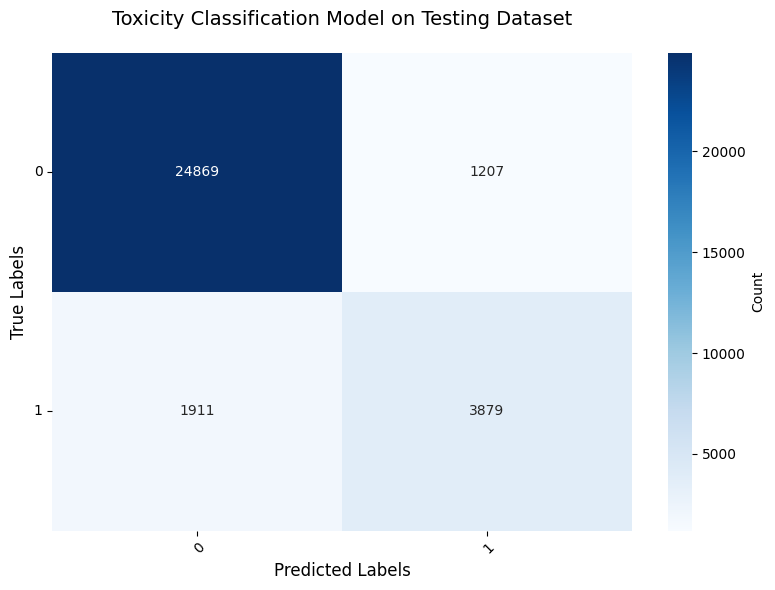

Accuracy: 0.9022
Precision: 0.8457
Recall: 0.8118
F1 Score: 0.8272


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Check the performance of the sarcasm analysis model on sarcasm_validation_dataset
def test_toxicity_model():
  labels = toxicity_test_set["toxicity"]
  pred_labels = toxicity_test_set["best_predictions"]

  plot_confusion_matrix(
      pred_labels, labels,
      title="Toxicity Classification Model on Testing Dataset"
                        )

  accuracy = accuracy_score(labels, pred_labels)
  precision = precision_score(labels, pred_labels, average='macro')
  recall = recall_score(labels, pred_labels, average='macro')
  f1 = f1_score(labels, pred_labels, average='macro')

  # Print all metrics
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1 Score: {f1:.4f}")

test_toxicity_model()

In [ ]:
def demo(comment):
  results = run_toxicity_prediction(comment);
  score = 0

  for item in results:
    score += item

  return "Toxic" if score / len(results) >= 0.37 else "Non-toxic"

print(demo("Die"))

NameError: name 'run_toxicity_prediction' is not defined